## Step-by-step instructions to assemble HEST data 


### I. Visium reader
This tutorial will guide you to convert a legacy Visium sample into a HEST-compatible object. 


### Download Visium sample from NCBI

In [ ]:
%%bash
# As an example, download the files from the following NCBI study:
# https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM6215674)

mkdir downloads
cd downloads
wget https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6215nnn/GSM6215674/suppl/GSM6215674%5FS13.png.gz
gunzip GSM6215674_S13.png.gz
wget https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6215nnn/GSM6215674/suppl/GSM6215674%5FS13%5Ffiltered%5Ffeature%5Fbc%5Fmatrix.h5

### Create HESTData object from the image and count matrix 

The library performs:

- Creation of AnnData object
- Creation of OpenSlide object 
- Automatic fiducial detection for spot alignment 

**Troubleshooting:**

If you encounter: `SystemError: ffi_prep_closure(): bad user_data (it seems that the version of the libffi library`. Attempt: `pip install --force-reinstall --no-binary :all: cffi`

alignment file is  None
AnnData object with n_obs × n_vars = 1182 × 32298
    var: 'gene_ids', 'feature_types', 'genome'


/home/guillaumejaume/anaconda3/envs/hest/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/guillaumejaume/anaconda3/envs/hest/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


trim the barcodes
no tissue_positions_list.csv/tissue_positions.csv or alignment file found
attempt fiducial auto alignment...

0: 608x640 1 filled_hexagon, 1 open_hexagon, 1 hourglass, 2 triangles, 10.6ms
Speed: 1.7ms preprocess, 10.6ms inference, 7.9ms postprocess per image at shape (1, 3, 608, 640)


/home/guillaumejaume/Documents/project_rosai/HEST/src/hest/autoalign.py:111: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(x, y, c='b', s=15, facecolors='none', linewidth=0.2)
/home/guillaumejaume/Documents/project_rosai/HEST/src/hest/autoalign.py:126: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circles2 = [plt.Circle(aligned_fiducials[i] * factor, radius=s_fid, color='r', facecolor='none', linewidth=0.3) for i in range(len(aligned_fiducials))]


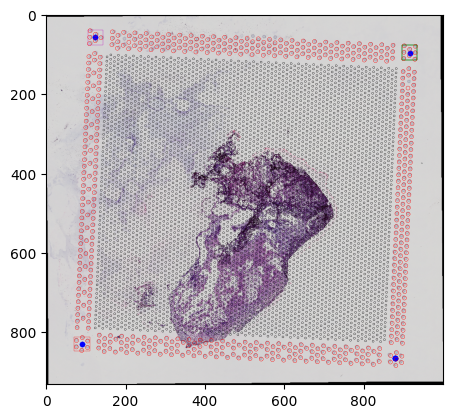

In [1]:
from hest import VisiumReader

fullres_img_path = 'downloads/GSM6215674_S13.png'
bc_matrix_path = 'downloads/GSM6215674_S13_filtered_feature_bc_matrix.h5'

st = VisiumReader().read(
    fullres_img_path, # path to a full res image
    bc_matrix_path, # path to filtered_feature_bc_matrix.h5
    save_autoalign=True # pass this argument to visualize the fiducial autodetection
)

In [2]:
st.save(path='processed')

saving to pyramidal tiff... can be slow


You can also visualize an overlay of the aligned spots on the downscaled WSI

/home/guillaumejaume/Documents/project_rosai/HEST/src/hest/HESTData.py:1583: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(adata, show=False, img_key="downscaled_fullres", color=[key], title=f"in_tissue spots", return_fig=True, **pl_kwargs)


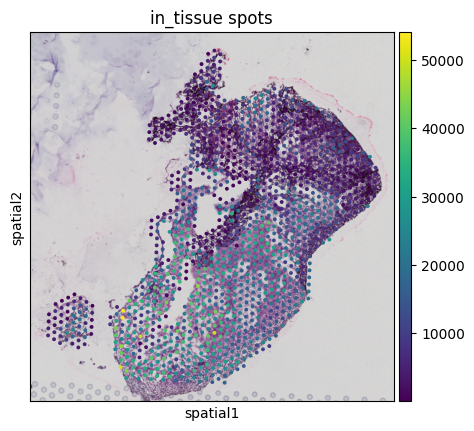

In [3]:
st.save_spatial_plot(save_path='processed')

### When should I provide an alignment file and when should I use autoalignment?

#### Step 1: check if a tissue_positions.csv/tissue_position_list.csv already provides a correct alignment

In most cases, if a `spatial/` folder containing a `tissue_positions.csv` or `tissue_position_list.csv` is available you don't need any autoalignment/alignment file.

Try the following:

`st = VisiumReader().read(fullres_img_path, bc_matric_path, spatial_coord_path=spatial_path)`, where `spatial_path` is contains `tissue_positions.csv` or `tissue_position_list.csv`. You can manually inspect the alignment by saving a visualization plot that takes the full resolution image, downscale it and overlays it with the spots (using `st.save_spatial_plot(save_dir)`). If the alignment is incorrect, try step 2.

#### Step 2: check if a .json alignment file is provided

If a `.json` alignment file is available, try: `VisiumReader().read(fullres_img_path, bc_matric_path, spatial_coord_path=spatial_path, alignment_file_path=align_path)`. You can also omit the `spatial_coord_path` as `VisiumReader().read(fullres_img_path, bc_matric_path, alignment_file_path=align_path)`

#### Step 3: attempt auto-alignment

If at least 3 corner fiducials are not cropped out and are reasonably visible, you can attempt an autoalignment with `VisiumReader().read(fullres_img_path, bc_matric_path`. (if no spatial folder and no alignment_file_path is provided, it will attempt autoalignment by default, you can also force auto-alignment by passing `autoalign='always'`). 

### Examples:

In [4]:
from hest import VisiumReader

fullres_img_path = 'my_path/image.tif'
bc_matrix_path = 'my_path/filtered_bc_matrix.h5'
spatial_coord_path = 'my_path/spatial'
alignment_file_path = 'my_path/alignment.txt'

st = VisiumReader().read(
    fullres_img_path, # path to a full res image
    bc_matrix_path, # path to filtered_feature_bc_matrix.h5
    spatial_coord_path=spatial_coord_path # path to a space ranger spatial/ folder containing either a tissue_positions.csv or tissue_position_list.csv
)

# if no spatial folder is provided, but you have an alignment file
st = VisiumReader().read(
    fullres_img_path, # path to a full res image
    bc_matrix_path, # path to filtered_feature_bc_matrix.h5
    alignment_file_path=alignment_file_path # path to a .json alignment file
)

# if both the alignment file and the spatial folder are missing, attempt auto-alignment
st = VisiumReader().read(
    fullres_img_path, # path to a full res image
    bc_matrix_path, # path to filtered_feature_bc_matrix.h5
)


alignment file is  None


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'my_path/filtered_bc_matrix.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

### Auto read
Given that `visium_dir` contains a full resolution image and all the necessary Visium files such as the `filtered_bc_matrix.h5` and the `spatial` folder, `VisiumReader.auto_read(path)` should be able to automatically read the sample. Prefer `read` for a more fine grain control.


In [ ]:
from hest import VisiumReader

# Set this to a folder containing a full-res image, filtered matrix and spatial files.
visium_dir = "PATH_TO_VISIUM_DIR"

# attempt autoread
st = VisiumReader().auto_read(visium_dir)

### II. Xenium reader

### Download Xenium sample from 10x genomics website

Download the following xenium files and place them in the same directory

https://www.10xgenomics.com/datasets/human-skin-data-xenium-human-multi-tissue-and-cancer-panel-1-standard

In [ ]:
%%bash

mkdir downloads
cd downloads
wget https://cf.10xgenomics.com/samples/xenium/1.9.0/Xenium_V1_hSkin_nondiseased_section_1_FFPE/Xenium_V1_hSkin_nondiseased_section_1_FFPE_outs.zip
unzip Xenium_V1_hSkin_nondiseased_section_1_FFPE_outs.zip -d Xenium_V1_hSkin_nondiseased_section_1_FFPE_outs

In [ ]:
%%bash

cd downloads/Xenium_V1_hSkin_nondiseased_section_1_FFPE_outs
wget https://cf.10xgenomics.com/samples/xenium/1.9.0/Xenium_V1_hSkin_nondiseased_section_1_FFPE/Xenium_V1_hSkin_nondiseased_section_1_FFPE_he_image.ome.tif
wget https://cf.10xgenomics.com/samples/xenium/1.9.0/Xenium_V1_hSkin_nondiseased_section_1_FFPE/Xenium_V1_hSkin_nondiseased_section_1_FFPE_he_imagealignment.csv

In [ ]:
from hest import XeniumReader

xenium_folder_path = 'downloads/Xenium_V1_hSkin_nondiseased_section_1_FFPE_outs'

st = XeniumReader().auto_read(xenium_folder_path)

### Working with larger than RAM Xenium samples (Xenium 5k)
We support larger than RAM transcripts pooling powered by dask. Dask will automatically chunk the data such that it never has to hold the entire transcript dataframe in memory.

Dask will attempt to process one partition per thread. To avoid loading large partitions on systems having a low amount of RAM, we advise using a high number of partitions (>100), as well as a single worker and a low number of threads (<4 depending on RAM available).

> Note: feel free to open the dask dashboard to visualize workers, partitions and resources (usually on http://localhost:8787)

In [ ]:
from dask.distributed import LocalCluster, Client

cluster = LocalCluster(
    "127.0.0.1:8786",
    n_workers=1, # increase depending on RAM available
    memory_limit="20GB", # dask will kill the worker if this is exceeded
    threads_per_worker=1, # increase depending on RAM available
)
client = Client(cluster)
print('dashboard is available at: ', client.dashboard_link)

st = XeniumReader().auto_read(
    xenium_folder_path, 
    use_dask=True, 
    nb_partitions=100
)

In [ ]:
st.save_spatial_plot('./')

In [ ]:
st.segment_tissue()

We then compute patches centered around pseudo-visium transcript bins.

> Warning: note that patches might be larger than transcript bins. 

In [ ]:
st.dump_patches('patches', target_patch_size=224, target_pixel_size=0.5)

In [ ]:
st.save('save', save_img=False)

### Adding new samples to HEST
This section explains how to format new samples for HuggingFace

### I. Sample preparation

#### 1. Download raw datasets in structured folders

Create the following folder structure:
```python
my_data/
    xenium/
        dataset_name_1/
            subseries1/
                sample_1/
                    ...
                sample_2/
                    ...
                ...
        dataset_name_2/
            sample_1/
                ...
    visium-hd/
        ...
    visium/
        ...
```

Then, download corresponding files for xenium, visium, visium-hd... See reader examples above or refer to the doc for the list of required files.

#### 2. Add metadata rows to CSV
Fill columns in the sample CSV, specifically: dataset_title, subseries should match with the folder structure.

### II. Sample processing

#### 1. Process raw samples

Set the path to your sample CSV in `tutorials/scripts/1_process_raw_samples.py`, also modify the memory_limit, we recommend setting dask memory limit to at least 20GB for Xenium 5k, eventhough 30GB is safer.

Process and save raw samples by launching `python tutorials/scripts/1_process_raw_samples.py`.

Processing Xenium 5k will take time, you can monitor progress on the dask dashboard (usually at `localhost:8787` after launch).


#### 2. Check Xenium DAPI/HE alignment and realign if necessary

By default, the Xenium platform uses a single affine transform for the whole WSI. For some samples, the resulting alignment might be unsatisfactory.
In order to visualize the affine alignment, either:
- open the resulting `.geojson` files (in `processed/`) in QuPath (might not work with QuPath >=0.6) \
\
or
<br/> 
<br/> 
- launch `tutorials/scripts/2_check_xenium_alignment.py`. 

#### 3. Micro-align DAPI to HE with Valis

If the alignment from steps (1-2) is unsatisfactory, we highly recommend using Valis non-rigid micro-alignment for sub-cellular alignment precision. This is crucial for correctly mapping transcripts and cells to H&E.


##### a. Register DAPI to HE with Valis

We provide a modified Valis version for simplified pythonic use and improved precision, please check-out the original repository [here](https://github.com/MathOnco/valis).

Open [3a_microalign_xenium.py](./scripts/3a_microalign_xenium.py), in this example, we use `morphology_focus_0000.ome.tif` as the DAPI slide, feel free to use `morphology_focus.ome.tif`.

Monitor alignment quality at `results/{sample_name}/{date}/overlaps/`, check both `_rigid_overlap.png` and `micro_reg.png`.


##### b. Warp transcripts, cells and nuclei using Valis and Dask

See [3b_microalign_xenium.py](./scripts/3b_microalign_xenium.py) to warp transcripts, nuclei and cells from DAPI to H&E.

Then re-run step 3.b, in order to compare quality.

#### 4. Segment with CellViT

See [4_segment_cellvit.py](./scripts/4_segment_cellvit.py) to segment with CellViT.


#### 5. Copy processed files to HEST_results/

See [5_copy_processed.py](./scripts/5_copy_processed.py) to copy files to the structure expected by huggingface.


#### 6. Generate a new HEST_vX_Y_Z.csv sheet

See [6_generate_new_meta.py](./scripts/6_generate_new_meta.py) to create a new HEST_vX_Y_Z.csv. Once created, copy it to the `HEST_results/` folder.


#### 7. Upload to HuggingFace

See [7_upload_huggingface.py](./scripts/7_upload_huggingface.py) to upload to HuggingFace via a PR.

